In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

2067387


In [4]:
all_data = {}


folder_path = "Data_C_alpha"


for file in os.listdir(folder_path):
    if file.endswith(".pkl"):    #and (file== "data_PF00014.pkl" or file== "data_PF01640.pkl")
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        filename=str(file)
        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']


        data = {
                'sequence': sequence,
                'distance_map_C_alpha': distance_map,
                'dca': contact_map_DCA
            }


        all_data[filename] = data




folder_path = "Data"

for file in os.listdir(folder_path):
    if file.endswith(".pkl"):    #and (file== "data_PF00014.pkl" or file== "data_PF01640.pkl")
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        filename=str(file)
        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']

        if filename in all_data:

            if np.array_equal(contact_map_DCA, all_data[filename]['dca']):

                all_data[filename]['distance_map'] = distance_map

            else:
                print(f'{filename} DCA mismatch')


        else:
            print(f'{filename} not found')


data_PF00010.pkl not found


Filename: data_PF00013.pkl


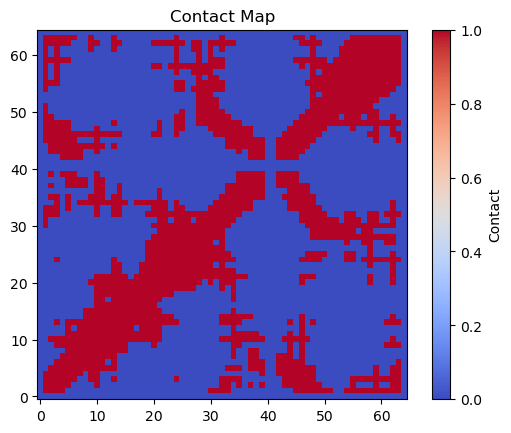

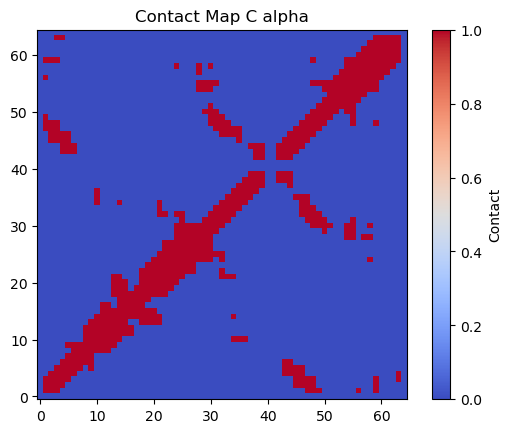

Filename: data_PF00014.pkl


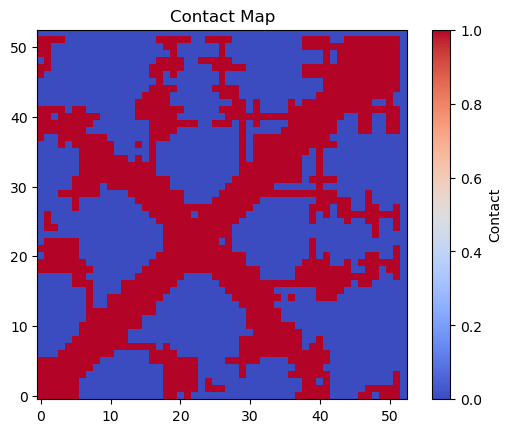

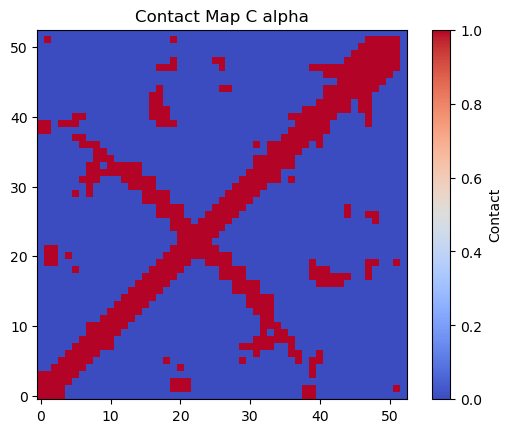

Filename: data_PF00017.pkl


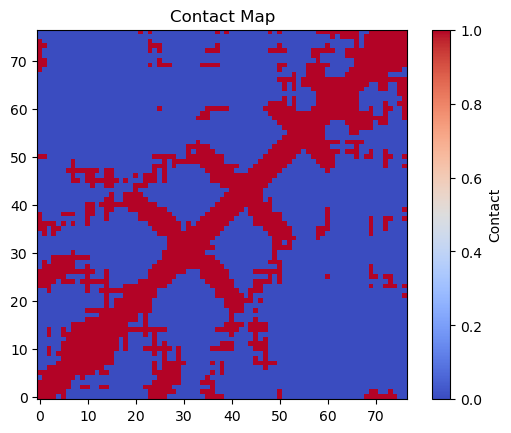

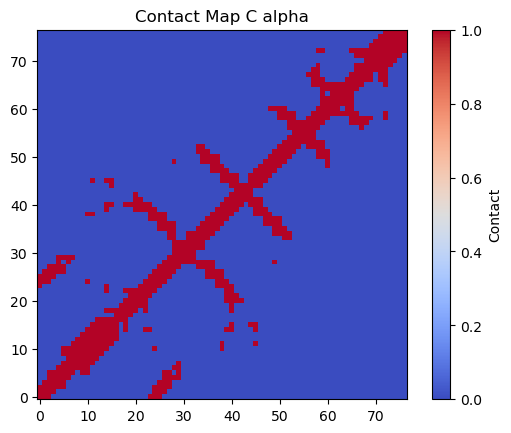

Filename: data_PF00019.pkl


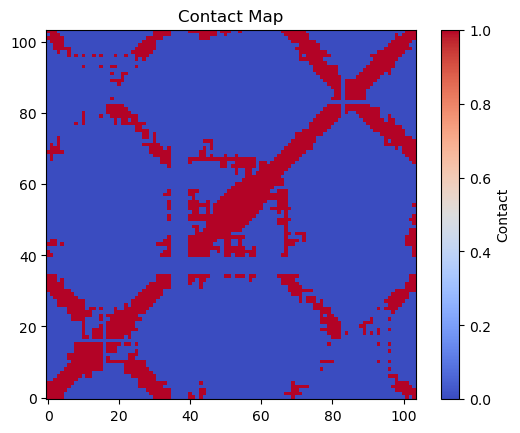

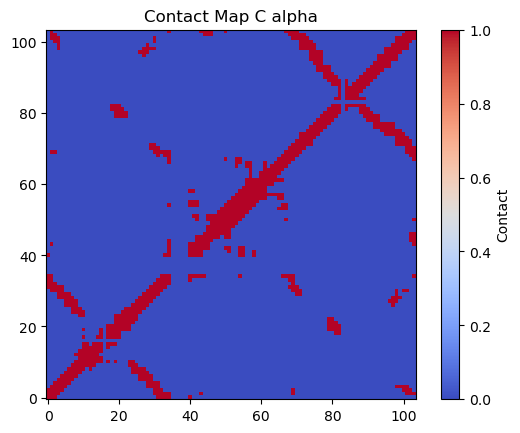

Filename: data_PF00037.pkl


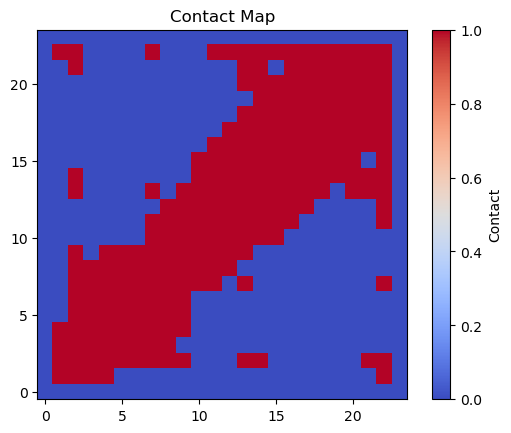

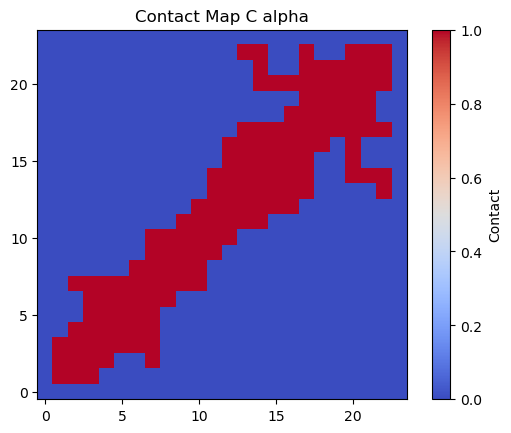

In [6]:
def contact_from_distance(distance_map, threshold=8.0):
    contact_map = (distance_map < threshold).astype(int)
    return contact_map  


i=0
for filename, data in all_data.items():

    print(f"Filename: {filename}")

    dm_C_alpha = data['distance_map_C_alpha']
    dm_min = data['distance_map']

    contact_map = contact_from_distance(dm_min, threshold=8.0)
    contact_map_C_alpha = contact_from_distance(dm_C_alpha, threshold=8.0)

    isfinite = np.isfinite(dm_C_alpha)

    plt.figure()
    plt.imshow(contact_map,cmap='coolwarm', origin='lower')
    plt.colorbar(label="Contact")
    plt.title("Contact Map")
    plt.show()

    plt.figure()
    plt.imshow(contact_map_C_alpha,cmap='coolwarm', origin='lower')
    plt.colorbar(label="Contact")
    plt.title("Contact Map C alpha")
    plt.show()

    i+=1
    if i==5:
        break

Text(0.5, 1.0, 'MSE between Contact Maps vs Threshold')

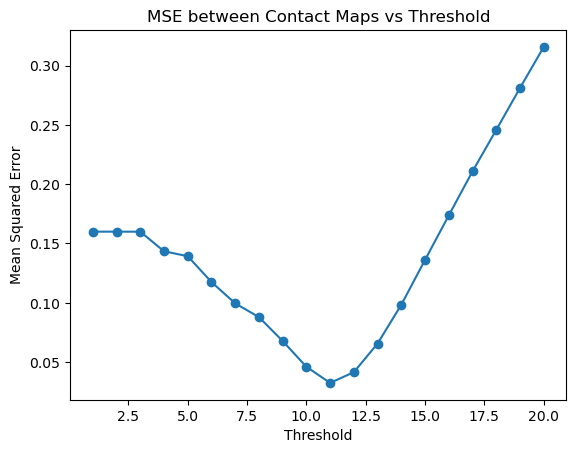

In [10]:
tr=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
mse_tr=[]

for t in tr:
    
    mse_tot=[]

    for filename, data in all_data.items():

        dm_C_alpha = data['distance_map_C_alpha']
        dm_min = data['distance_map']

        contact_map = contact_from_distance(dm_min, threshold=8.0)
        contact_map_C_alpha = contact_from_distance(dm_C_alpha, threshold=t)

        isfinite = np.isfinite(dm_C_alpha)

        mse = np.mean((contact_map - contact_map_C_alpha)**2)
        mse_tot.append(mse)

    mse_tr.append(np.mean(mse_tot))

plt.figure()
plt.plot(tr, mse_tr, marker='o')
plt.xlabel('Threshold')
plt.ylabel('Mean Squared Error')
plt.title('MSE between Contact Maps vs Threshold')

Text(0.5, 1.0, 'MSE between Contact Maps vs Threshold')

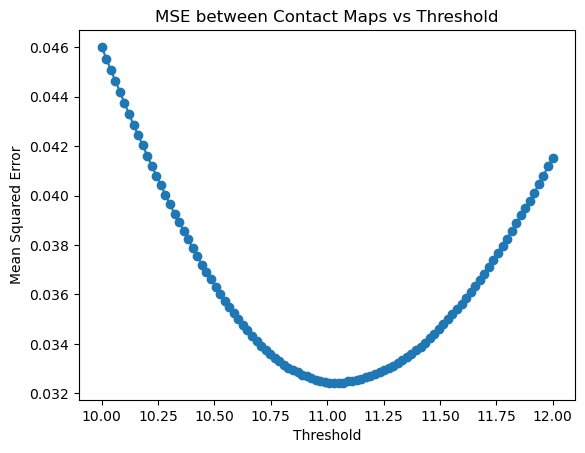

In [ ]:
#mse

tr= np.linspace(10, 12, 100)
mse_tr=[]

for t in tr:
    
    mse_tot=[]

    for filename, data in all_data.items():

        dm_C_alpha = data['distance_map_C_alpha']
        dm_min = data['distance_map']

        contact_map = contact_from_distance(dm_min, threshold=8.0)
        contact_map_C_alpha = contact_from_distance(dm_C_alpha, threshold=t)

        isfinite = np.isfinite(dm_C_alpha)

        mse = np.mean((contact_map - contact_map_C_alpha)**2)
        mse_tot.append(mse)

    mse_tr.append(np.mean(mse_tot))

plt.figure()
plt.plot(tr, mse_tr, marker='o')
plt.xlabel('Threshold')
plt.ylabel('Mean Squared Error')
plt.title('MSE between Contact Maps vs Threshold')

Text(0.5, 1.0, 'Jaccard Index between Contact Maps vs Threshold')

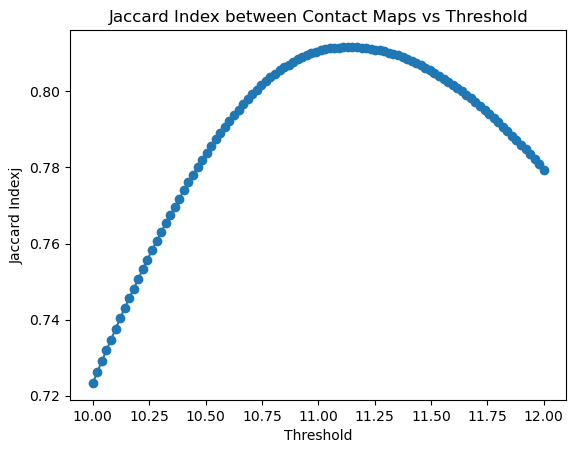

In [13]:
#jaccard

tr= np.linspace(10, 12, 100)
mse_tr=[]

for t in tr:
    
    mse_tot=[]

    for filename, data in all_data.items():

        dm_C_alpha = data['distance_map_C_alpha']
        dm_min = data['distance_map']

        contact_map = contact_from_distance(dm_min, threshold=8.0)
        contact_map_C_alpha = contact_from_distance(dm_C_alpha, threshold=t)

        isfinite = np.isfinite(dm_C_alpha)

        intersection = np.logical_and(contact_map, contact_map_C_alpha).sum()
        union = np.logical_or(contact_map, contact_map_C_alpha).sum()

        jaccard = intersection / union if union > 0 else 0

        mse_tot.append(jaccard)

    mse_tr.append(np.mean(mse_tot))

plt.figure()
plt.plot(tr, mse_tr, marker='o')
plt.xlabel('Threshold')
plt.ylabel('Jaccard Indexj')
plt.title('Jaccard Index between Contact Maps vs Threshold')